# Analisis de pruebas MinPol

Este notebook consolida las pruebas realizadas sobre el modelo MiniZinc para el problema MinPol. Se analizan tres grupos de datos: la instancia base del enunciado, las cinco instancias propias del grupo y la bateria de pruebas entregada por el profesor.

El objetivo no es solo mostrar resultados, sino interpretar el comportamiento del modelo: que tan buena es la solucion, que restricciones parecen mas activas y como cambia el tiempo de ejecucion segun el tamano y la naturaleza de las instancias.


In [31]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

GRAFICOS_DIR = Path('graficos')
GRAFICOS_DIR.mkdir(exist_ok=True)

# Resultados generados por Resultados/ejecutar_pruebas.py
df = pd.read_csv('resultados_pruebas.csv')
bateria = pd.read_csv('resultados_bateria_pruebas.csv')

# Conversion segura de columnas numericas
for data in (df, bateria):
    for col in [
        'n', 'm', 'ct', 'MaxMovs', 'polarizacion', 'costo_usado',
        'movimientos_usados', 'personas_movidas', 'porcentaje_presupuesto',
        'porcentaje_movimientos', 'tiempo_segundos', 'valor_esperado',
        'diferencia_abs'
    ]:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce')

def guardar(nombre):
    plt.tight_layout()
    plt.savefig(GRAFICOS_DIR / nombre, dpi=160, bbox_inches='tight')
    plt.show()


## 1. Vista general de las instancias propias

Esta tabla resume la instancia base y las cinco instancias propias. Incluye tamano, restricciones principales, polarizacion final, costo usado, movimientos usados y tiempo de ejecucion.


In [32]:
cols_propias = [
    'instancia', 'n', 'm', 'ct', 'MaxMovs', 'estado_solver',
    'polarizacion', 'costo_usado', 'movimientos_usados',
    'personas_movidas', 'porcentaje_presupuesto',
    'porcentaje_movimientos', 'tiempo_segundos'
]
df[cols_propias]


,instancia,n,m,ct,MaxMovs,estado_solver,polarizacion,costo_usado,movimientos_usados,personas_movidas,porcentaje_presupuesto,porcentaje_movimientos,tiempo_segundos
0,base_enunciado,20,5,20.0,18,optimo,0.50,19.200000,14,8,96.00,77.78,0.1083
1,instancia_01_facil,12,4,18.0,15,optimo,0.00,13.416667,9,9,74.54,60.00,0.1053
2,instancia_02_presupuesto_bajo,24,5,14.0,14,optimo,7.75,14.000000,6,4,100.00,42.86,0.1262
3,instancia_03_opiniones_vacias,18,5,18.0,16,optimo,6.00,17.333333,6,3,96.30,37.50,0.1460
4,instancia_04_extremos,40,5,28.0,30,optimo,13.75,27.550000,19,19,98.39,63.33,0.1470
5,instancia_05_grande,28,5,30.0,24,optimo,4.00,29.785714,21,18,99.29,87.50,0.1166


## 2. Polarizacion final por instancia propia

**Proposito:** comparar que tan polarizada queda la poblacion despues de aplicar el modelo en la instancia base y en cada instancia propia.

**Por que esta grafica es ideal:** una grafica de barras permite comparar facilmente valores finales de polarizacion entre casos distintos. Es adecuada porque la polarizacion es una medida escalar y cada instancia produce un unico valor final.


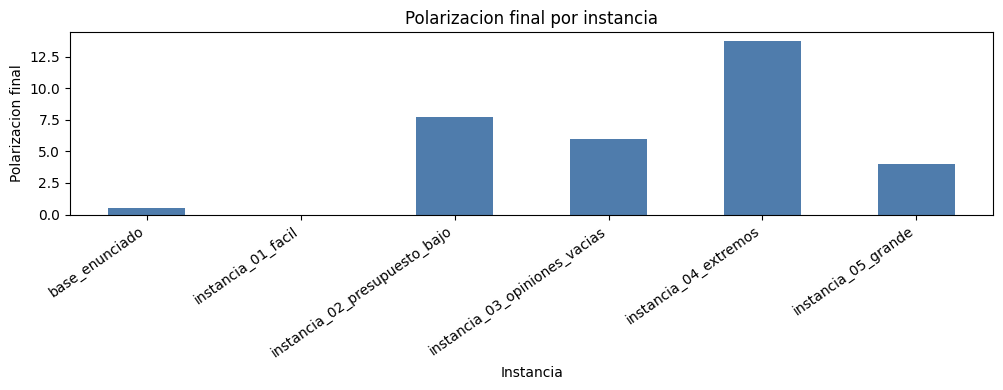

In [49]:
ax = df.plot(
    kind='bar', x='instancia', y='polarizacion', legend=False,
    figsize=(10, 4), color='#4f7cac', title='Polarizacion final por instancia'
)
ax.set_xlabel('Instancia')
ax.set_ylabel('Polarizacion final')
plt.xticks(rotation=35, ha='right')
guardar('01_polarizacion_instancias_propias.png')


**Conclusion:** se observa que `instancia_01_facil` alcanza polarizacion `0`, mientras que `instancia_04_extremos` conserva la polarizacion mas alta. Esto ocurre porque en la instancia facil el presupuesto y los movimientos disponibles permiten llevar la poblacion hacia una configuracion de consenso, mientras que en la instancia de extremos la poblacion parte mucho mas separada y no es posible concentrarla totalmente sin violar las restricciones. Por lo tanto, la polarizacion final depende tanto de los recursos disponibles como de la distribucion inicial de opiniones.


## 3. Porcentaje de presupuesto usado

**Proposito:** identificar que tan cerca queda cada solucion del costo maximo permitido `ct`.

**Por que esta grafica es ideal:** usar porcentaje permite comparar instancias con presupuestos diferentes. Si se graficara solo el costo absoluto, una instancia con mayor `ct` pareceria mas costosa aunque no necesariamente este mas limitada.


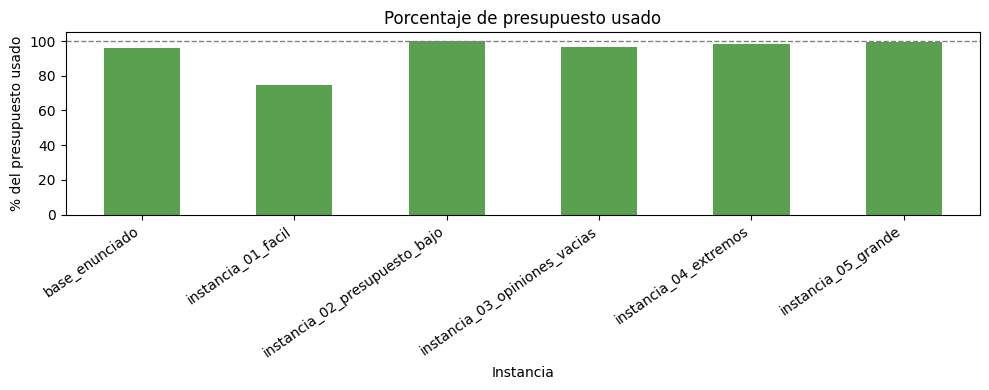

In [35]:
ax = df.plot(
    kind='bar', x='instancia', y='porcentaje_presupuesto', legend=False,
    figsize=(10, 4), color='#59a14f', title='Porcentaje de presupuesto usado'
)
ax.set_xlabel('Instancia')
ax.set_ylabel('% del presupuesto usado')
ax.axhline(100, color='gray', linestyle='--', linewidth=1)
plt.xticks(rotation=35, ha='right')
guardar('02_porcentaje_presupuesto_usado.png')


**Conclusion:** se observa que varias instancias usan casi todo el presupuesto disponible, especialmente `instancia_02_presupuesto_bajo`, `instancia_04_extremos` e `instancia_05_grande`. Esto ocurre porque el modelo intenta aprovechar los recursos economicos para reducir la polarizacion tanto como sea posible. Por lo tanto, en estas instancias el presupuesto actua como una restriccion fuerte: si se aumentara `ct`, probablemente el modelo podria explorar movimientos adicionales y reducir mas la polarizacion.


## 4. Porcentaje de movimientos usados

**Proposito:** revisar si el limite `MaxMovs` esta restringiendo la solucion de forma importante.

**Por que esta grafica es ideal:** al igual que con el presupuesto, el porcentaje permite comparar instancias con limites de movimientos distintos. La grafica ayuda a distinguir si el modelo se queda corto por falta de movimientos o por falta de presupuesto.


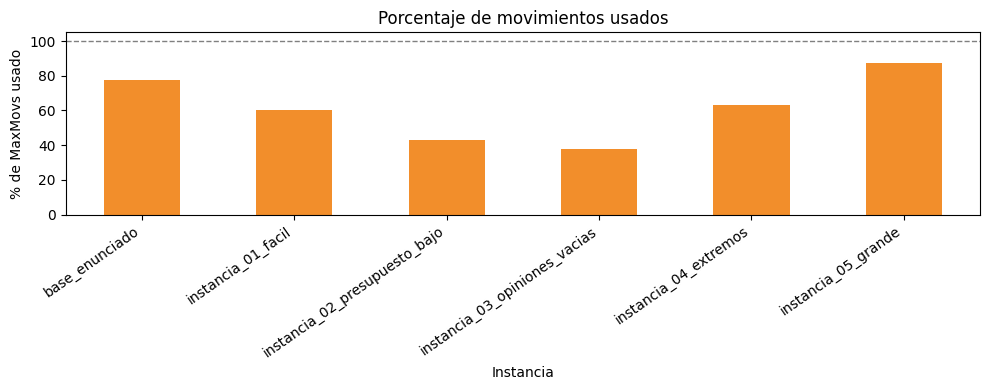

In [36]:
ax = df.plot(
    kind='bar', x='instancia', y='porcentaje_movimientos', legend=False,
    figsize=(10, 4), color='#f28e2b', title='Porcentaje de movimientos usados'
)
ax.set_xlabel('Instancia')
ax.set_ylabel('% de MaxMovs usado')
ax.axhline(100, color='gray', linestyle='--', linewidth=1)
plt.xticks(rotation=35, ha='right')
guardar('03_porcentaje_movimientos_usados.png')


**Conclusion:** se observa que algunas instancias usan una parte moderada del limite de movimientos, mientras que otras se acercan mucho al maximo permitido. Esto ocurre porque no todos los cambios de opinion tienen la misma distancia: mover personas entre opiniones cercanas consume pocos movimientos, pero moverlas entre extremos consume mas. Por lo tanto, `MaxMovs` no siempre es la restriccion principal; en varios casos el presupuesto se agota antes de usar todos los movimientos disponibles.


## 5. Personas movidas por instancia

**Proposito:** medir que tan intensa fue la intervencion propuesta por el modelo en cada instancia.

**Por que esta grafica es ideal:** una grafica de barras permite ver directamente cuantas personas cambian de opinion. Esta metrica complementa la polarizacion, porque dos soluciones pueden tener polarizacion parecida pero requerir cantidades muy distintas de cambios.


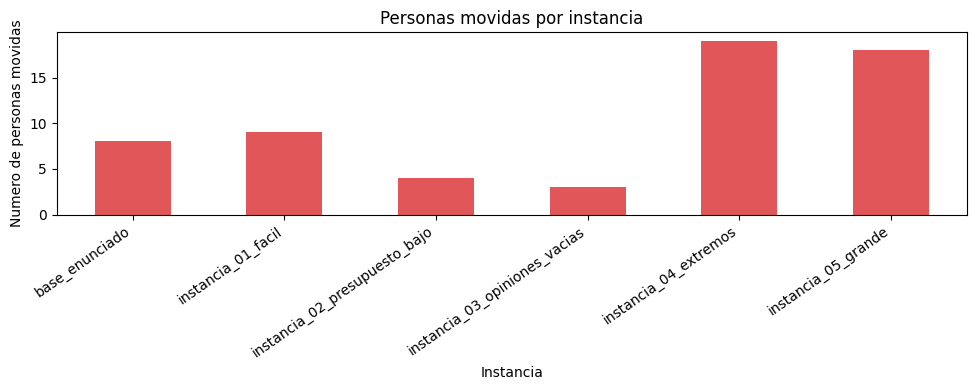

In [37]:
ax = df.plot(
    kind='bar', x='instancia', y='personas_movidas', legend=False,
    figsize=(10, 4), color='#e15759', title='Personas movidas por instancia'
)
ax.set_xlabel('Instancia')
ax.set_ylabel('Numero de personas movidas')
plt.xticks(rotation=35, ha='right')
guardar('04_personas_movidas.png')


**Conclusion:** se observa que las instancias no requieren la misma cantidad de movimientos de personas. Esto ocurre porque el modelo no busca mover la mayor cantidad posible, sino mover aquellas personas cuyo cambio reduce mas la polarizacion respetando costo y distancia. Por lo tanto, una intervencion mas grande no siempre significa una mejor solucion; lo importante es hacia donde se mueven las personas y cuanto cuesta cada movimiento.


## 6. Tiempo de ejecucion por instancia propia

**Proposito:** comparar que instancias propias son mas exigentes computacionalmente.

**Por que esta grafica es ideal:** una grafica de barras permite identificar rapidamente casos atipicos de tiempo. Es util para el informe porque el proyecto no solo pide obtener soluciones, sino analizar el comportamiento de las pruebas.


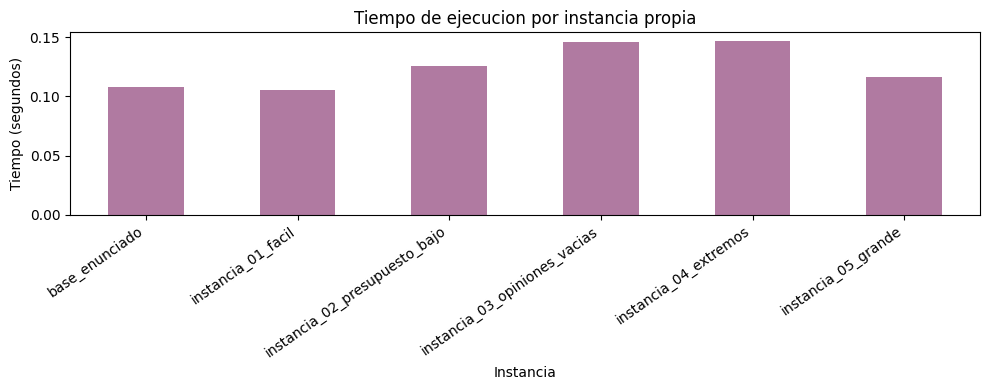

In [38]:
ax = df.plot(
    kind='bar', x='instancia', y='tiempo_segundos', legend=False,
    figsize=(10, 4), color='#b07aa1', title='Tiempo de ejecucion por instancia propia'
)
ax.set_xlabel('Instancia')
ax.set_ylabel('Tiempo (segundos)')
plt.xticks(rotation=35, ha='right')
guardar('05_tiempo_instancias_propias.png')


**Conclusion:** se observa que los tiempos son bajos en la mayoria de instancias propias. Esto ocurre porque el modelo se esta resolviendo con un solver MIP adecuado y porque estas instancias tienen tamanos controlados. Por lo tanto, para las pruebas propias el modelo es practico y permite obtener soluciones optimas sin tiempos excesivos.


## 7. Bateria de pruebas

Esta seccion valida el modelo contra las instancias entregadas por el profesor y sus soluciones esperadas. Las pruebas `MinPol28` y `MinPol29` tienen una inconsistencia en los datos: declaran `n = 100`, pero la suma de la distribucion inicial es `125`. Por eso aparecen como infactibles o sin resultado comparable.


In [51]:
cols_bateria = [
    'instancia', 'n', 'm', 'estado_solver', 'polarizacion',
    'valor_esperado', 'diferencia_abs', 'comparacion_esperada',
    'tiempo_segundos', 'observaciones'
]
bateria[cols_bateria]


,instancia,n,m,estado_solver,polarizacion,valor_esperado,diferencia_abs,comparacion_esperada,tiempo_segundos,observaciones
0,MinPol1,5,5,optimo,0.090,0.090,0.000,coincide,0.1280,NaN
1,MinPol2,5,5,optimo,0.000,0.000,0.000,coincide,0.0924,NaN
2,MinPol3,5,10,optimo,0.000,0.000,0.000,coincide,0.1356,NaN
3,MinPol4,10,5,optimo,0.000,0.000,0.000,coincide,0.1056,NaN
4,MinPol5,10,5,optimo,0.482,0.482,0.000,coincide,0.1241,NaN
5,MinPol6,20,5,optimo,0.003,0.003,0.000,coincide,0.1077,NaN
6,MinPol7,35,5,optimo,3.085,3.085,0.000,coincide,0.1658,NaN
7,MinPol8,35,5,optimo,4.323,4.323,0.000,coincide,0.0995,NaN
8,MinPol9,50,5,optimo,5.373,5.373,0.000,coincide,0.0987,NaN
9,MinPol10,50,5,optimo,9.687,9.686,0.001,coincide,0.0898,NaN


## 8. Estado del solver en la bateria del pruebas

**Proposito:** resumir cuantas instancias de la bateria fueron resueltas hasta optimalidad y cuantas presentaron problemas.

**Por que esta grafica es ideal:** una grafica de barras por categorias es adecuada porque el estado del solver no es numerico sino cualitativo: `optimo`, `infeasible`, `timeout`, entre otros.


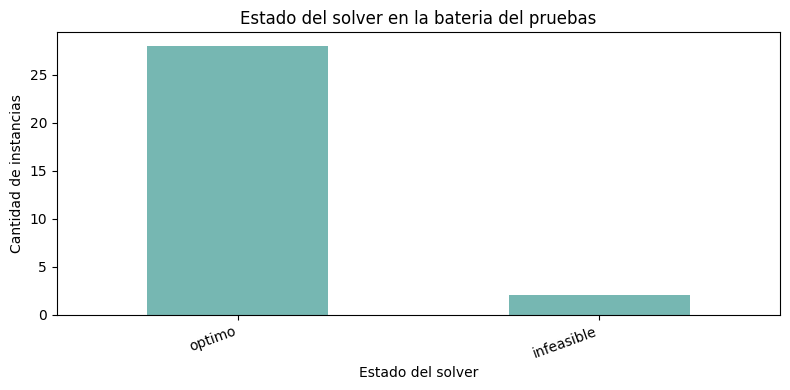

In [50]:
estado_counts = bateria['estado_solver'].value_counts()
ax = estado_counts.plot(
    kind='bar', figsize=(8, 4), color='#76b7b2',
    title='Estado del solver en la bateria del pruebas'
)
ax.set_xlabel('Estado del solver')
ax.set_ylabel('Cantidad de instancias')
plt.xticks(rotation=20, ha='right')
guardar('06_estado_solver_bateria.png')


**Conclusion:** se observa que la mayoria de instancias de la bateria llegan a estado optimo, mientras que las problematicas corresponden a casos con datos inconsistentes. Esto ocurre porque el modelo puede resolver las instancias bien formadas, pero no puede satisfacer simultaneamente `n = 100` y una distribucion inicial que suma `125`. Por lo tanto, los fallos no indican necesariamente un error del modelo, sino una inconsistencia en esas entradas especificas.


## 9. Valor obtenido vs valor esperado

**Proposito:** validar si el modelo produce los mismos valores de polarizacion que la solucion entregada por el profesor.

**Por que esta grafica es ideal:** una grafica de lineas con marcadores permite comparar dos series sobre las mismas instancias. Si las lineas se superponen, visualmente se confirma que el modelo coincide con la bateria esperada.


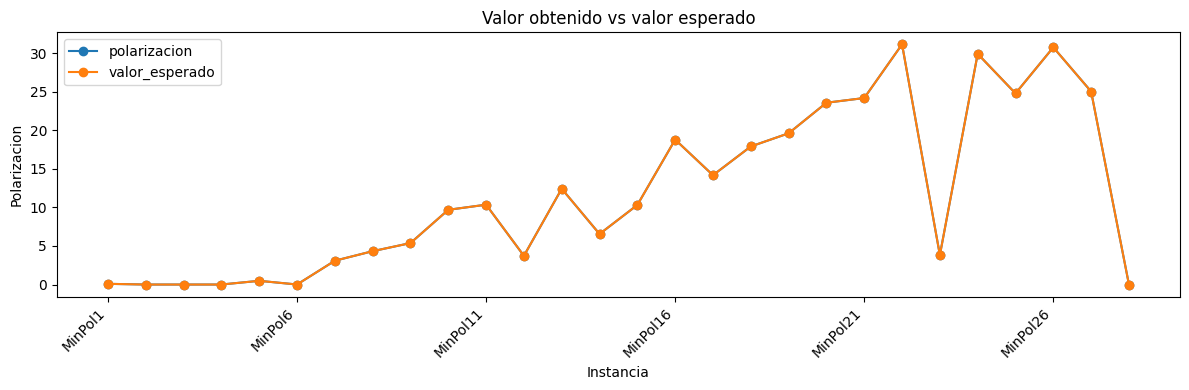

In [41]:
comparables = bateria[bateria['comparacion_esperada'].isin(['coincide', 'diferente'])].copy()
ax = comparables.plot(
    x='instancia', y=['polarizacion', 'valor_esperado'],
    figsize=(12, 4), marker='o', title='Valor obtenido vs valor esperado'
)
ax.set_xlabel('Instancia')
ax.set_ylabel('Polarizacion')
plt.xticks(rotation=45, ha='right')
guardar('07_valor_obtenido_vs_esperado.png')


**Conclusion:** se observa que los valores obtenidos por el modelo coinciden con los valores esperados en las instancias comparables. Esto ocurre porque la formulacion implementa correctamente la funcion objetivo y las restricciones principales del problema. Por lo tanto, la bateria del pruebas sirve como evidencia externa de que el modelo no solo funciona en las instancias creadas por el grupo, sino tambien en casos independientes.


## 10. Diferencia absoluta contra la solucion esperada

**Proposito:** medir numericamente que tan lejos esta el valor obtenido del valor esperado.

**Por que esta grafica es ideal:** una grafica de barras de diferencia absoluta facilita detectar rapidamente si alguna instancia tiene una discrepancia relevante. Es mas clara que revisar manualmente muchos decimales en una tabla.


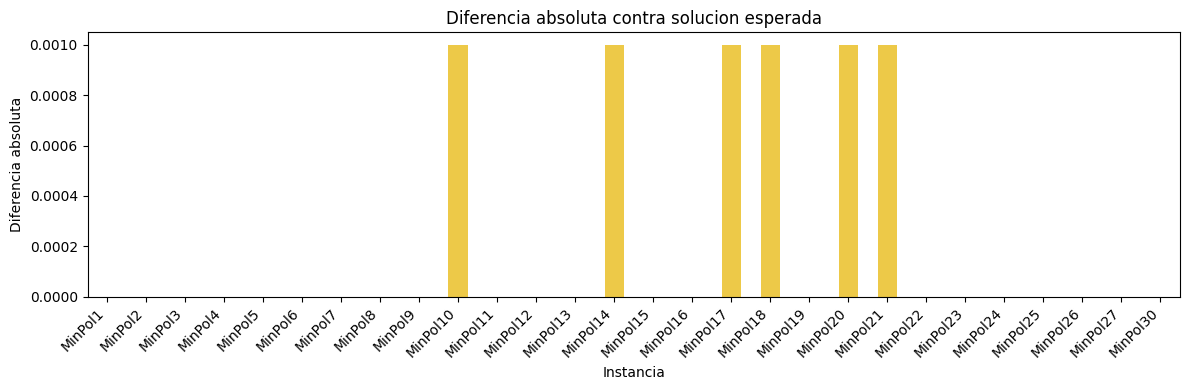

In [42]:
errores = bateria[pd.to_numeric(bateria['diferencia_abs'], errors='coerce').notna()].copy()
errores['diferencia_abs'] = errores['diferencia_abs'].astype(float)
ax = errores.plot(
    kind='bar', x='instancia', y='diferencia_abs', legend=False,
    figsize=(12, 4), color='#edc948', title='Diferencia absoluta contra solucion esperada'
)
ax.set_xlabel('Instancia')
ax.set_ylabel('Diferencia absoluta')
plt.xticks(rotation=45, ha='right')
guardar('08_diferencia_absoluta_esperado.png')


**Conclusion:** se observa que la diferencia absoluta es cero o practicamente cero en las instancias comparables. Esto ocurre porque las pequenas diferencias que pueden aparecer son de redondeo decimal entre MiniZinc y el CSV de soluciones. Por lo tanto, no hay evidencia de desviaciones significativas frente a la bateria esperada.


## 11. Tamaño del problema vs tiempo de ejecucion

**Proposito:** analizar si el tiempo de ejecucion aumenta cuando crece el tamano del problema.

**Por que esta grafica es ideal:** la cantidad de variables de movimiento `x[i,j]` crece aproximadamente como `m^2`, por eso usar `m^2` como eje horizontal ayuda a representar mejor el tamano estructural del modelo que usar solo `m`.


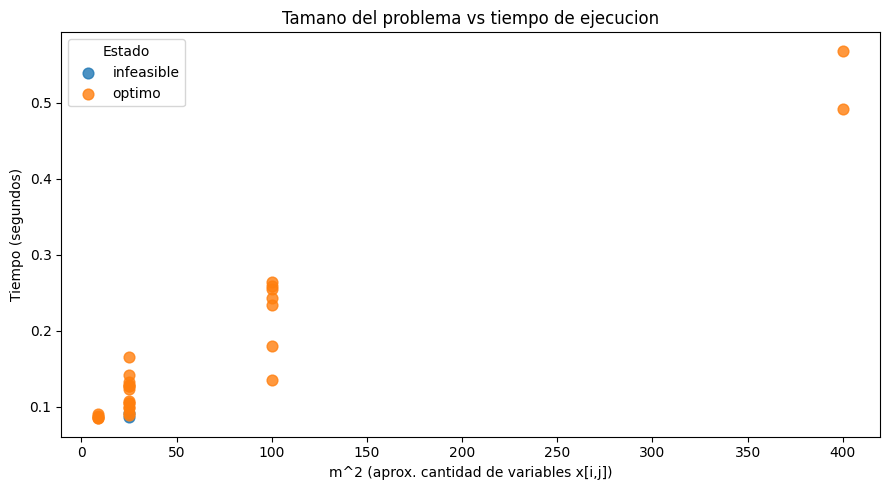

In [54]:
bateria_tam = bateria.copy()
bateria_tam['m2'] = bateria_tam['m'] ** 2
bateria_tam['grupo'] = bateria_tam['estado_solver']

fig, ax = plt.subplots(figsize=(9, 5))
for estado, data in bateria_tam.groupby('grupo'):
    ax.scatter(data['m2'], data['tiempo_segundos'], label=estado, s=60, alpha=0.8)
ax.set_title('Tamano del problema vs tiempo de ejecucion')
ax.set_xlabel('m^2 (aprox. cantidad de variables x[i,j])')
ax.set_ylabel('Tiempo (segundos)')
ax.legend(title='Estado')
guardar('09_tamano_vs_tiempo_bateria.png')


**Conclusion:** se observa que las instancias con mayor `m^2` tienden a ser estructuralmente mas grandes, aunque el tiempo no crece de forma perfectamente uniforme. Esto ocurre porque el tiempo tambien depende de los costos, la distribucion inicial, el presupuesto y el limite de movimientos, no solo del numero de opiniones. Por lo tanto, el tamano del problema ayuda a explicar el desempeno, pero no es el unico factor que determina la dificultad computacional.


## 12. Top 10 tiempos de ejecucion en la bateria

**Proposito:** identificar las instancias de la bateria que mas tiempo tardaron en resolverse.

**Por que esta grafica es ideal:** ordenar y mostrar solo el top 10 evita una grafica saturada con las 30 pruebas. Esto permite enfocar el analisis en los casos que mas aportan a la discusion de rendimiento.


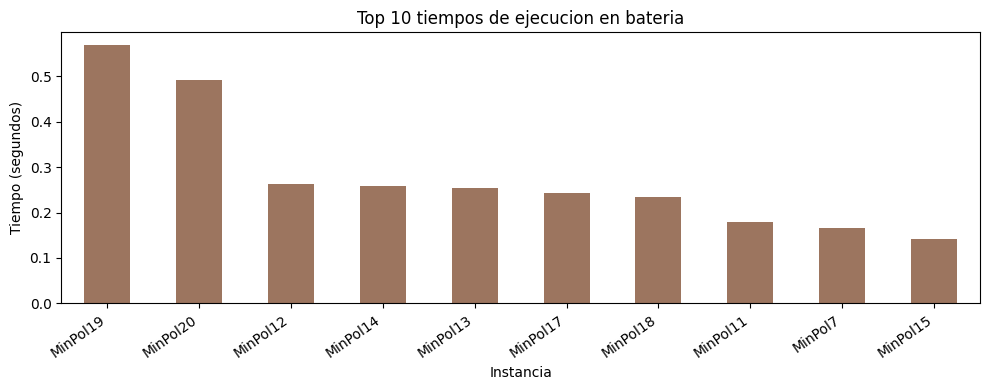

In [44]:
top_tiempo = bateria.sort_values('tiempo_segundos', ascending=False).head(10)
ax = top_tiempo.plot(
    kind='bar', x='instancia', y='tiempo_segundos', legend=False,
    figsize=(10, 4), color='#9c755f', title='Top 10 tiempos de ejecucion en bateria'
)
ax.set_xlabel('Instancia')
ax.set_ylabel('Tiempo (segundos)')
plt.xticks(rotation=35, ha='right')
guardar('10_top10_tiempos_bateria.png')


**Conclusion:** se observa que solo algunas instancias concentran los mayores tiempos de ejecucion. Esto ocurre porque ciertas combinaciones de presupuesto, movimientos permitidos y distribucion inicial generan una busqueda mas exigente para probar optimalidad. Por lo tanto, el analisis de rendimiento debe considerar casos especificos y no solo promedios generales.


## 13. Conclusiones generales

Se observa que el modelo logra resolver correctamente las instancias propias y coincide con las soluciones esperadas de la bateria del pruebas en los casos comparables. Esto ocurre porque la formulacion conserva las restricciones del problema: presupuesto, movimientos maximos, conservacion de poblacion y calculo de polarizacion respecto a la mediana. Por lo tanto, los resultados respaldan que el modelo es adecuado para representar el problema MinPol.

Tambien se observa que el presupuesto suele usarse en un porcentaje alto en varias instancias. Esto ocurre porque el modelo aprovecha los recursos disponibles para mover personas hacia configuraciones menos polarizadas. Por lo tanto, el costo total permitido es una restriccion clave para explicar por que algunas instancias no alcanzan consenso.

Finalmente, se observa que el tiempo de ejecucion no depende solamente de `n` o `m`, sino de la estructura completa de la instancia. Esto ocurre porque el solver debe evaluar combinaciones de movimientos, costos y restricciones de mediana. Por lo tanto, para analizar el rendimiento del modelo conviene revisar tanto el tamano del problema como la naturaleza de los datos.
